# Лабораторная работа №6. Понижение размерности. Отбор и извлечение признаков.

## Цель работы

Изучить и сравнить методы понижения размерности признакового пространства на двух прикладных задачах — классификации и регрессии. Работа включает два направления:

- **Отбор признаков (Feature Selection)** — выбор подмножества исходных признаков, которые наиболее информативны для задачи.
- **Извлечение признаков (Feature Extraction)** — построение нового пространства меньшей размерности путём преобразования исходных признаков.

## Датасеты

| Датасет | Задача | Строк | Признаков | Целевая переменная |
|---------|--------|------:|----------:|-------------------|
| asteroids_cleaned.csv | Классификация | 88 534 | 5 | hazardous (0/1) |
| cars_cleaned.csv | Регрессия | 38 491 | 47 | price_usd |

## Применяемые методы

| # | Метод | Категория |
|---|-------|-----------|
| 1 | VarianceThreshold | Отбор признаков |
| 2 | SelectKBest | Отбор признаков |
| 3 | RFE | Отбор признаков |
| 4 | PCA | Извлечение признаков |
| 5 | Kernel PCA (poly, rbf, sigmoid) | Извлечение признаков |
| 6 | t-SNE | Извлечение признаков |
| 7 | Isomap | Извлечение признаков |
| 8 | UMAP | Извлечение признаков |

In [ ]:
import os
os.environ['PYTHONIOENCODING'] = 'utf-8'
os.environ['LOKY_MAX_CPU_COUNT'] = '8'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import VarianceThreshold, SelectKBest, RFE, f_classif, f_regression
from sklearn.decomposition import PCA, KernelPCA
from sklearn.manifold import TSNE, Isomap
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    r2_score, mean_squared_error, mean_absolute_error
)
try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False
    print('umap-learn не установлен. Запустите: pip install umap-learn')

## 1. Загрузка данных — Классификация (asteroids)

**Датасет:** сведения о потенциально опасных астероидах NASA.

**Признаки:**

| Признак | Описание |
|---------|----------|
| year | Год наблюдения |
| est_diameter_max | Максимальный оценочный диаметр (км) |
| relative_velocity | Относительная скорость сближения с Землёй (км/с) |
| miss_distance | Расстояние минимального сближения с Землёй (км) |
| absolute_magnitude | Абсолютная звёздная величина |

**Целевая переменная:** `hazardous` — является ли астероид потенциально опасным (1) или нет (0).

**Дисбаланс классов:** в датасете около 90% объектов принадлежат классу 0. Без коррекции модель будет предсказывать преимущественно 0 и получать высокую Accuracy при низких Recall и F1. Для исправления применяется **SMOTE** (Synthetic Minority Oversampling Technique) — метод синтетической генерации примеров миноритарного класса. SMOTE применяется **только к тренировочным данным**, тестовая выборка остаётся несбалансированной, как в реальных условиях.

In [2]:
df_clf = pd.read_csv('asteroids_cleaned.csv')
X_clf = df_clf.drop('hazardous', axis=1)
y_clf = df_clf['hazardous']

scaler_clf = StandardScaler()
X_clf_s = scaler_clf.fit_transform(X_clf)

X_clf_tr, X_clf_te, y_clf_tr, y_clf_te = train_test_split(
    X_clf_s, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

# Балансировка train через SMOTE (pip install imbalanced-learn)
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_clf_tr, y_clf_tr = smote.fit_resample(X_clf_tr, y_clf_tr)

print(f'Классификация: {X_clf_s.shape}, признаки: {list(X_clf.columns)}')
print(f'Классы test (оригинал): {pd.Series(y_clf_te).value_counts().to_dict()}')
print(f'Классы train после SMOTE: {pd.Series(y_clf_tr).value_counts().to_dict()}')

Классификация: (88534, 5), признаки: ['year', 'est_diameter_max', 'relative_velocity', 'miss_distance', 'absolute_magnitude']
Классы test (оригинал): {0: 15988, 1: 1719}
Классы train после SMOTE: {0: 63950, 1: 63950}


## 2. Загрузка данных — Регрессия (cars)

**Датасет:** объявления о продаже автомобилей.

**Признаки (47):** технические характеристики и комплектация — тип трансмиссии, пробег, год выпуска, объём двигателя, тип кузова, наличие опций (feature_1 — feature_9), тип топлива и другие. Значительная часть признаков — бинарные (one-hot encoded), поэтому их дисперсия невысока.

**Целевая переменная:** `price_usd` — цена автомобиля в долларах США.

Все признаки стандартизированы (`StandardScaler`) перед применением методов понижения размерности. Это необходимо, поскольку признаки имеют разные единицы измерения и масштабы.

In [3]:
df_reg = pd.read_csv('cars_cleaned.csv')
X_reg = df_reg.drop('price_usd', axis=1)
y_reg = df_reg['price_usd']

scaler_reg = StandardScaler()
X_reg_s = scaler_reg.fit_transform(X_reg)

X_reg_tr, X_reg_te, y_reg_tr, y_reg_te = train_test_split(
    X_reg_s, y_reg, test_size=0.2, random_state=42
)
print(f'Регрессия: {X_reg_s.shape}')
print(f'Target range: {y_reg.min():.0f}–{y_reg.max():.0f}')

Регрессия: (38491, 47)
Target range: 1–50000


## 3. Baseline-модели (все признаки)

Перед применением методов понижения размерности обучаются модели на **полном наборе признаков**. Полученные метрики используются как эталонное значение для оценки потерь или улучшений от каждого метода.

Используется `RandomForestClassifier` / `RandomForestRegressor` с `n_estimators=50`. Все последующие модели используют те же гиперпараметры — это обеспечивает корректное сравнение: разница в метриках объясняется только изменением признакового пространства, а не настройками алгоритма.

In [4]:
# Фабричные функции — меняй n_estimators здесь, применится везде
def make_clf():
    return RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)

def make_reg():
    return RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)

In [5]:
clf_base = make_clf()
clf_base.fit(X_clf_tr, y_clf_tr)
y_clf_pred_base = clf_base.predict(X_clf_te)
BASELINE_ACC  = accuracy_score(y_clf_te, y_clf_pred_base)
BASELINE_PREC = precision_score(y_clf_te, y_clf_pred_base)
BASELINE_REC  = recall_score(y_clf_te, y_clf_pred_base)
BASELINE_F1   = f1_score(y_clf_te, y_clf_pred_base)

reg_base = make_reg()
reg_base.fit(X_reg_tr, y_reg_tr)
y_reg_pred_base = reg_base.predict(X_reg_te)
BASELINE_R2   = r2_score(y_reg_te, y_reg_pred_base)
BASELINE_MSE  = mean_squared_error(y_reg_te, y_reg_pred_base)
BASELINE_RMSE = np.sqrt(BASELINE_MSE)
BASELINE_MAE  = mean_absolute_error(y_reg_te, y_reg_pred_base)

print(f'Baseline CLF  | Acc={BASELINE_ACC:.4f}  Prec={BASELINE_PREC:.4f}  Rec={BASELINE_REC:.4f}  F1={BASELINE_F1:.4f}')
print(f'Baseline REG  | R²={BASELINE_R2:.4f}  MSE={BASELINE_MSE:.2f}  RMSE={BASELINE_RMSE:.2f}  MAE={BASELINE_MAE:.2f}')

results_clf = []
results_reg = []

def add_clf(method, n_feat, y_pred):
    results_clf.append({
        'Метод': method, 'N признаков': n_feat,
        'Accuracy':  round(accuracy_score(y_clf_te, y_pred), 4),
        'Precision': round(precision_score(y_clf_te, y_pred), 4),
        'Recall':    round(recall_score(y_clf_te, y_pred), 4),
        'F1':        round(f1_score(y_clf_te, y_pred), 4),
    })

def add_reg(method, n_feat, y_pred):
    mse = mean_squared_error(y_reg_te, y_pred)
    results_reg.append({
        'Метод': method, 'N признаков': n_feat,
        'R²':   round(r2_score(y_reg_te, y_pred), 4),
        'MSE':  round(mse, 2),
        'RMSE': round(np.sqrt(mse), 2),
        'MAE':  round(mean_absolute_error(y_reg_te, y_pred), 2),
    })

add_clf('Baseline', X_clf_s.shape[1], y_clf_pred_base)
add_reg('Baseline', X_reg_s.shape[1], y_reg_pred_base)

Baseline CLF  | Acc=0.9378  Prec=0.6723  Rec=0.7004  F1=0.6860
Baseline REG  | R²=0.8940  MSE=4285002.79  RMSE=2070.02  MAE=1221.57


---

## Задание 3.1 — Методы отбора признаков (Feature Selection)

Методы отбора выбирают подмножество **исходных признаков**, не создавая новых. Интерпретируемость модели сохраняется: можно точно сказать, какие признаки используются. Каждый метод оценивается на тех же тестовых данных, что и baseline.

---

### Метод 1: VarianceThreshold

Удаляет признаки, дисперсия которых ниже заданного порога. Полезен для удаления константных или почти константных столбцов — например, бинарных признаков, у которых значение 1 встречается очень редко (низкая дисперсия по всей выборке).

- **Классификация:** датасет содержит только 5 числовых признаков, все с достаточной дисперсией — ни один не удаляется, результат совпадает с baseline.
- **Регрессия:** среди 47 признаков фильтруются редкие бинарные столбцы, оставшихся признаков достаточно для сохранения качества.

In [6]:
vt_clf = VarianceThreshold(threshold=0.1)
X_clf_vt_tr = vt_clf.fit_transform(X_clf_tr)
X_clf_vt_te = vt_clf.transform(X_clf_te)
clf_names_vt = np.array(X_clf.columns)[vt_clf.get_support()]
print(f'[CLF] VarianceThreshold: {X_clf_vt_tr.shape[1]} признаков — {list(clf_names_vt)}')
clf_vt = make_clf().fit(X_clf_vt_tr, y_clf_tr)
y_clf_vt = clf_vt.predict(X_clf_vt_te)
print(f'  Accuracy={accuracy_score(y_clf_te, y_clf_vt):.4f}  (baseline={BASELINE_ACC:.4f})')
add_clf('VarianceThreshold', X_clf_vt_tr.shape[1], y_clf_vt)

vt_reg = VarianceThreshold(threshold=0.1)
X_reg_vt_tr = vt_reg.fit_transform(X_reg_tr)
X_reg_vt_te = vt_reg.transform(X_reg_te)
print(f'\n[REG] VarianceThreshold: {X_reg_vt_tr.shape[1]} признаков')
reg_vt = make_reg().fit(X_reg_vt_tr, y_reg_tr)
y_reg_vt = reg_vt.predict(X_reg_vt_te)
print(f'  R²={r2_score(y_reg_te, y_reg_vt):.4f}  (baseline={BASELINE_R2:.4f})')
add_reg('VarianceThreshold', X_reg_vt_tr.shape[1], y_reg_vt)

[CLF] VarianceThreshold: 5 признаков — ['year', 'est_diameter_max', 'relative_velocity', 'miss_distance', 'absolute_magnitude']
  Accuracy=0.9378  (baseline=0.9378)

[REG] VarianceThreshold: 47 признаков
  R²=0.8940  (baseline=0.8940)


### Метод 2: SelectKBest

Отбирает `k` признаков с наибольшим значением статистического критерия:
- **Классификация:** ANOVA F-тест (`f_classif`), k=3 — измеряет, насколько средние значения признака различаются между классами.
- **Регрессия:** F-тест корреляции (`f_regression`), k=15 — оценивает линейную зависимость между признаком и целевой переменной.

Метод прост, быстр и интерпретируем, но оценивает признаки **независимо** — не учитывает взаимодействия и дублирование информации между ними. Признаки с высоким F-score не обязательно образуют оптимальный набор при совместном использовании.

In [7]:
skb_clf = SelectKBest(score_func=f_classif, k=3)
X_clf_skb_tr = skb_clf.fit_transform(X_clf_tr, y_clf_tr)
X_clf_skb_te = skb_clf.transform(X_clf_te)
clf_names_skb = np.array(X_clf.columns)[skb_clf.get_support()]
print(f'[CLF] SelectKBest (k=3): {list(clf_names_skb)}')
scores_df = pd.DataFrame({'Признак': X_clf.columns, 'F-score': skb_clf.scores_}).sort_values('F-score', ascending=False)
print(scores_df.to_string(index=False))
clf_skb = make_clf().fit(X_clf_skb_tr, y_clf_tr)
y_clf_skb = clf_skb.predict(X_clf_skb_te)
print(f'  Accuracy={accuracy_score(y_clf_te, y_clf_skb):.4f}  (baseline={BASELINE_ACC:.4f})')
add_clf('SelectKBest', 3, y_clf_skb)

skb_reg = SelectKBest(score_func=f_regression, k=15)
X_reg_skb_tr = skb_reg.fit_transform(X_reg_tr, y_reg_tr)
X_reg_skb_te = skb_reg.transform(X_reg_te)
reg_names_skb = np.array(X_reg.columns)[skb_reg.get_support()]
print(f'\n[REG] SelectKBest (k=15): {list(reg_names_skb)}')
reg_skb = make_reg().fit(X_reg_skb_tr, y_reg_tr)
y_reg_skb = reg_skb.predict(X_reg_skb_te)
print(f'  R²={r2_score(y_reg_te, y_reg_skb):.4f}  (baseline={BASELINE_R2:.4f})')
add_reg('SelectKBest', 15, y_reg_skb)

[CLF] SelectKBest (k=3): ['est_diameter_max', 'relative_velocity', 'absolute_magnitude']
           Признак      F-score
absolute_magnitude 84010.793467
  est_diameter_max 16099.032379
 relative_velocity 13250.964737
     miss_distance   804.376962
              year   219.560643
  Accuracy=0.8716  (baseline=0.9378)

[REG] SelectKBest (k=15): ['transmission', 'odometer_value', 'year_produced', 'engine_capacity', 'has_warranty', 'drivetrain', 'number_of_photos', 'feature_2', 'feature_3', 'feature_4', 'feature_5', 'feature_6', 'feature_7', 'feature_8', 'body_suv']
  R²=0.8560  (baseline=0.8940)


### Метод 3: RFE (Recursive Feature Elimination)

Итеративный метод: модель обучается на полном наборе признаков, определяет важность каждого, наименее важные признаки удаляются, процесс повторяется до достижения нужного числа k.

В отличие от SelectKBest, RFE учитывает **взаимодействие признаков**: признак, слабый сам по себе, может быть удалён, если его информация уже содержится в другом признаке.

В качестве базового эстиматора используется `DecisionTreeClassifier` / `DecisionTreeRegressor` — он даёт хорошие оценки важности и работает значительно быстрее Random Forest.

- Классификация: k=3, Регрессия: k=15
- Ранг 1 соответствует наиболее важным признакам (они отобраны), ранг > 1 — удалённым.

In [8]:
from sklearn.feature_selection import RFE
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

rfe_clf = RFE(estimator=DecisionTreeClassifier(random_state=42), n_features_to_select=3)
X_clf_rfe_tr = rfe_clf.fit_transform(X_clf_tr, y_clf_tr)
X_clf_rfe_te = rfe_clf.transform(X_clf_te)
clf_names_rfe = np.array(X_clf.columns)[rfe_clf.get_support()]
print(f'[CLF] RFE (k=3): {list(clf_names_rfe)}')
rank_df = pd.DataFrame({'Признак': X_clf.columns, 'Ранг': rfe_clf.ranking_}).sort_values('Ранг')
print(rank_df.to_string(index=False))
clf_rfe = make_clf().fit(X_clf_rfe_tr, y_clf_tr)
y_clf_rfe = clf_rfe.predict(X_clf_rfe_te)
print(f'  Accuracy={accuracy_score(y_clf_te, y_clf_rfe):.4f}  (baseline={BASELINE_ACC:.4f})')
add_clf('RFE', 3, y_clf_rfe)

rfe_reg = RFE(estimator=DecisionTreeRegressor(random_state=42), n_features_to_select=15)
X_reg_rfe_tr = rfe_reg.fit_transform(X_reg_tr, y_reg_tr)
X_reg_rfe_te = rfe_reg.transform(X_reg_te)
reg_names_rfe = np.array(X_reg.columns)[rfe_reg.get_support()]
print(f'\n[REG] RFE (k=15): {list(reg_names_rfe)}')
reg_rfe = make_reg().fit(X_reg_rfe_tr, y_reg_tr)
y_reg_rfe = reg_rfe.predict(X_reg_rfe_te)
print(f'  R²={r2_score(y_reg_te, y_reg_rfe):.4f}  (baseline={BASELINE_R2:.4f})')
add_reg('RFE', 15, y_reg_rfe)

[CLF] RFE (k=3): ['year', 'est_diameter_max', 'relative_velocity']
           Признак  Ранг
              year     1
  est_diameter_max     1
 relative_velocity     1
     miss_distance     2
absolute_magnitude     3
  Accuracy=0.9126  (baseline=0.9378)

[REG] RFE (k=15): ['manufacturer_name', 'transmission', 'odometer_value', 'year_produced', 'engine_capacity', 'drivetrain', 'number_of_photos', 'up_counter', 'feature_6', 'feature_8', 'feature_9', 'duration_listed', 'body_minibus', 'body_sedan', 'fuel_diesel']
  R²=0.8889  (baseline=0.8940)


---

## Задание 3.1 — Методы извлечения признаков (Feature Extraction)

В отличие от отбора, методы извлечения **строят новые признаки** как преобразования исходных. Полученные компоненты не имеют прямой содержательной интерпретации, но могут лучше отражать внутреннюю структуру данных.

Все методы применяются к **2 компонентам** — это позволяет визуализировать результат. Трансформатор обучается только на тренировочных данных (`fit` на train, `transform` на test), что предотвращает утечку информации о тестовой выборке.

---

### Метод 4: PCA (Principal Component Analysis)

Линейный метод. Ищет ортогональные направления (главные компоненты) с максимальной дисперсией данных. Первая компонента объясняет наибольшую долю дисперсии, вторая — наибольшую из оставшейся, и так далее.

- Не учитывает нелинейные зависимости между признаками.
- Быстрый и детерминированный.
- Процент объяснённой дисперсии показывает, какую долю исходной информации сохраняют 2 компоненты.

[CLF] PCA: объяснённая дисперсия = 71.7%
  Accuracy=0.7546  (baseline=0.9378)

[REG] PCA: объяснённая дисперсия = 19.5%
  R²=0.5352  (baseline=0.8940)


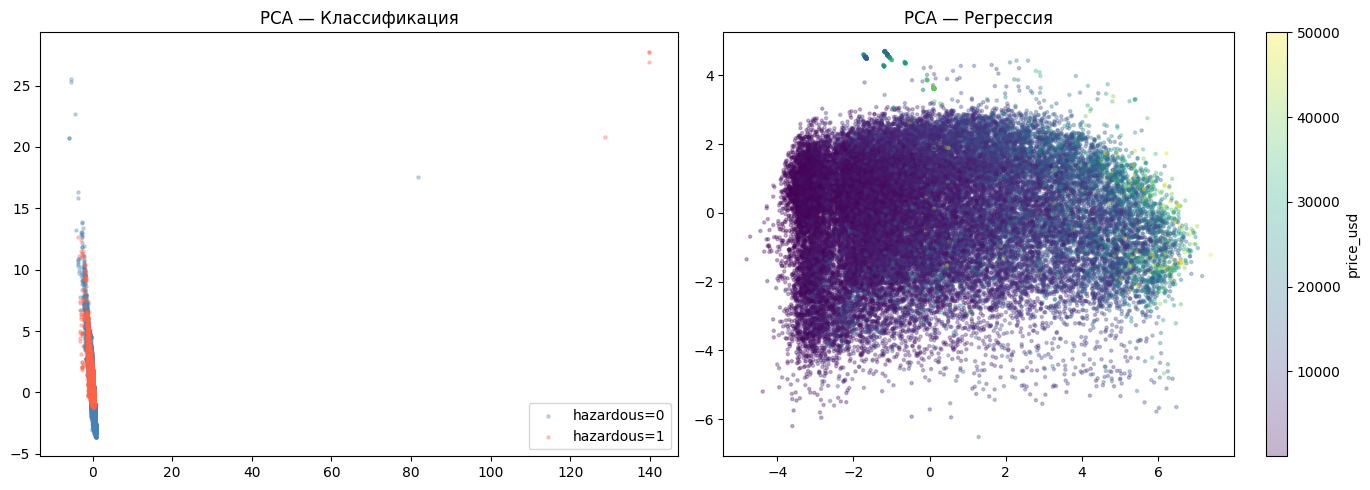

In [9]:
pca_clf = PCA(n_components=2, random_state=42)
X_clf_pca_tr = pca_clf.fit_transform(X_clf_tr)
X_clf_pca_te = pca_clf.transform(X_clf_te)
print(f'[CLF] PCA: объяснённая дисперсия = {pca_clf.explained_variance_ratio_.sum()*100:.1f}%')
clf_pca = make_clf().fit(X_clf_pca_tr, y_clf_tr)
y_clf_pca = clf_pca.predict(X_clf_pca_te)
print(f'  Accuracy={accuracy_score(y_clf_te, y_clf_pca):.4f}  (baseline={BASELINE_ACC:.4f})')
add_clf('PCA', 2, y_clf_pca)

pca_reg = PCA(n_components=2, random_state=42)
X_reg_pca_tr = pca_reg.fit_transform(X_reg_tr)
X_reg_pca_te = pca_reg.transform(X_reg_te)
print(f'\n[REG] PCA: объяснённая дисперсия = {pca_reg.explained_variance_ratio_.sum()*100:.1f}%')
reg_pca = make_reg().fit(X_reg_pca_tr, y_reg_tr)
y_reg_pca = reg_pca.predict(X_reg_pca_te)
print(f'  R²={r2_score(y_reg_te, y_reg_pca):.4f}  (baseline={BASELINE_R2:.4f})')
add_reg('PCA', 2, y_reg_pca)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
X_clf_pca_all = pca_clf.transform(X_clf_s)
for label, color in [(0, 'steelblue'), (1, 'tomato')]:
    mask = y_clf.values == label
    axes[0].scatter(X_clf_pca_all[mask, 0], X_clf_pca_all[mask, 1], c=color, alpha=0.3, s=5, label=f'hazardous={label}')
axes[0].set_title('PCA — Классификация'); axes[0].legend()
X_reg_pca_all = pca_reg.transform(X_reg_s)
sc = axes[1].scatter(X_reg_pca_all[:, 0], X_reg_pca_all[:, 1], c=y_reg.values, cmap='viridis', alpha=0.3, s=5)
plt.colorbar(sc, ax=axes[1], label='price_usd')
axes[1].set_title('PCA — Регрессия')
plt.tight_layout(); plt.show()

### Метод 5: Kernel PCA

Нелинейное обобщение PCA: данные неявно отображаются в пространство более высокой размерности через функцию ядра, затем применяется обычный PCA. Это позволяет улавливать нелинейные структуры, недоступные линейному PCA.

| Ядро | Описание |
|------|----------|
| poly | Полиномиальное — учитывает попарные взаимодействия признаков |
| rbf | Радиальная базисная функция — универсальное, наиболее часто используемое |
| sigmoid | Сигмоидное — аналогично активациям нейронных сетей |

Вычисление матрицы ядра на всех данных требует $O(n^2)$ памяти и времени. При n = 88 000 это даёт матрицу 88k × 88k, что неприемлемо. Поэтому трансформатор обучается на подвыборке **5 000 строк** из тренировочных данных, а затем применяется ко всем данным.


--- poly ---
[CLF] KernelPCA(poly): Accuracy=0.7498  (baseline=0.9378)
[REG] KernelPCA(poly): R²=0.3978  (baseline=0.8940)

--- rbf ---
[CLF] KernelPCA(rbf): Accuracy=0.7884  (baseline=0.9378)
[REG] KernelPCA(rbf): R²=0.4833  (baseline=0.8940)

--- sigmoid ---
[CLF] KernelPCA(sigmoid): Accuracy=0.7935  (baseline=0.9378)
[REG] KernelPCA(sigmoid): R²=0.5400  (baseline=0.8940)


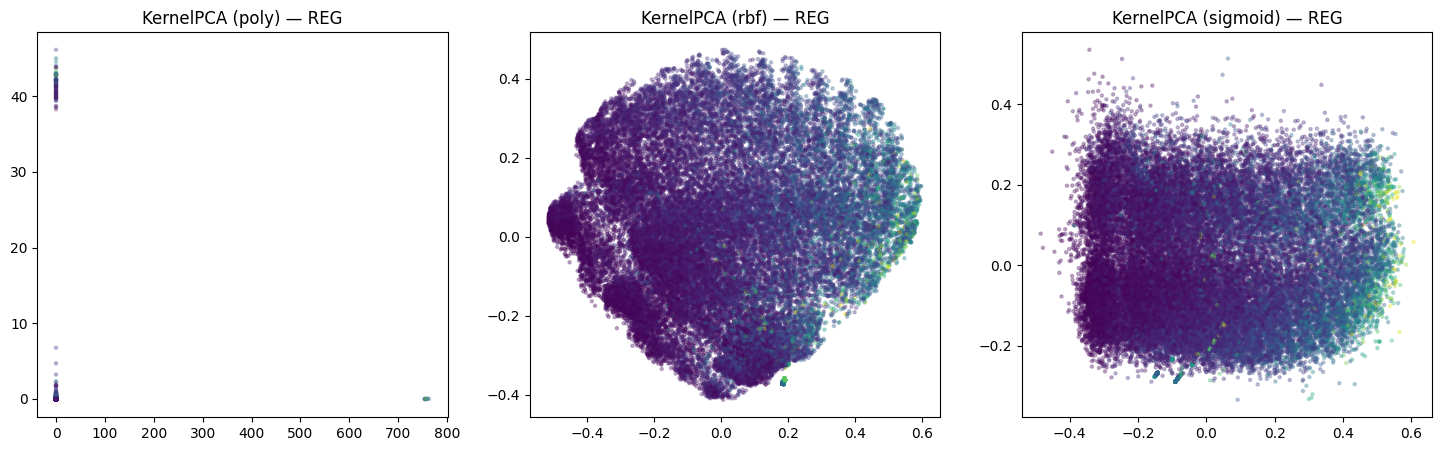

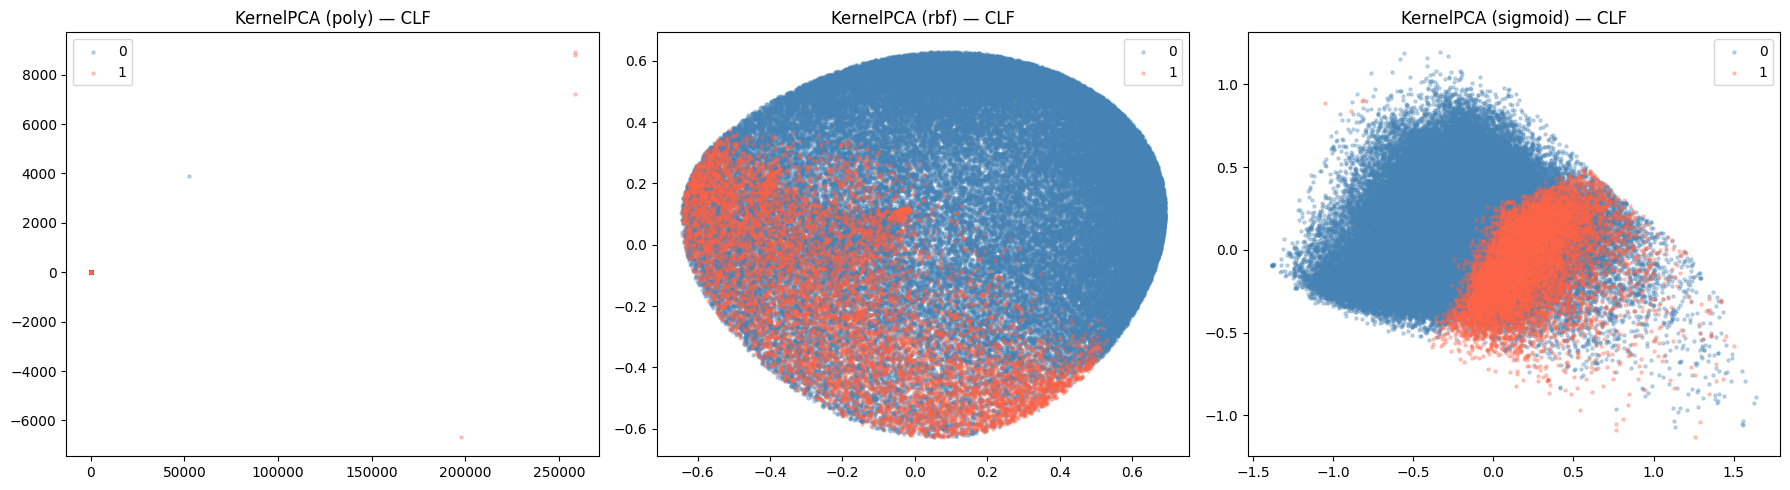

<Figure size 640x480 with 0 Axes>

In [10]:
KPCA_SAMPLE = 5000
rng = np.random.default_rng(42)
clf_sample_idx = rng.choice(len(X_clf_tr), size=min(KPCA_SAMPLE, len(X_clf_tr)), replace=False)
reg_sample_idx = rng.choice(len(X_reg_tr), size=min(KPCA_SAMPLE, len(X_reg_tr)), replace=False)
X_clf_kpca_fit = X_clf_tr[clf_sample_idx]
X_reg_kpca_fit = X_reg_tr[reg_sample_idx]

kernels = ['poly', 'rbf', 'sigmoid']
fig_clf, axes_clf = plt.subplots(1, 3, figsize=(18, 5))
fig_reg, axes_reg = plt.subplots(1, 3, figsize=(18, 5))

for i, kernel in enumerate(kernels):
    print(f'\n--- {kernel} ---')
    kpca_clf = KernelPCA(n_components=2, kernel=kernel, random_state=42)
    kpca_clf.fit(X_clf_kpca_fit)
    X_clf_kpca_tr = kpca_clf.transform(X_clf_tr)
    X_clf_kpca_te = kpca_clf.transform(X_clf_te)
    clf_kpca = make_clf().fit(X_clf_kpca_tr, y_clf_tr)
    y_clf_kpca = clf_kpca.predict(X_clf_kpca_te)
    print(f'[CLF] KernelPCA({kernel}): Accuracy={accuracy_score(y_clf_te, y_clf_kpca):.4f}  (baseline={BASELINE_ACC:.4f})')
    add_clf(f'KernelPCA ({kernel})', 2, y_clf_kpca)
    X_clf_kpca_all = kpca_clf.transform(X_clf_s)
    for label, color in [(0, 'steelblue'), (1, 'tomato')]:
        mask = y_clf.values == label
        axes_clf[i].scatter(X_clf_kpca_all[mask, 0], X_clf_kpca_all[mask, 1], c=color, alpha=0.3, s=5, label=f'{label}')
    axes_clf[i].set_title(f'KernelPCA ({kernel}) — CLF'); axes_clf[i].legend()

    kpca_reg = KernelPCA(n_components=2, kernel=kernel, random_state=42)
    kpca_reg.fit(X_reg_kpca_fit)
    X_reg_kpca_tr = kpca_reg.transform(X_reg_tr)
    X_reg_kpca_te = kpca_reg.transform(X_reg_te)
    reg_kpca = make_reg().fit(X_reg_kpca_tr, y_reg_tr)
    y_reg_kpca = reg_kpca.predict(X_reg_kpca_te)
    print(f'[REG] KernelPCA({kernel}): R²={r2_score(y_reg_te, y_reg_kpca):.4f}  (baseline={BASELINE_R2:.4f})')
    add_reg(f'KernelPCA ({kernel})', 2, y_reg_kpca)
    X_reg_kpca_all = kpca_reg.transform(X_reg_s)
    sc = axes_reg[i].scatter(X_reg_kpca_all[:, 0], X_reg_kpca_all[:, 1], c=y_reg.values, cmap='viridis', alpha=0.3, s=5)
    axes_reg[i].set_title(f'KernelPCA ({kernel}) — REG')

fig_clf.tight_layout(); plt.figure(fig_clf.number); plt.show()
fig_reg.tight_layout(); plt.figure(fig_reg.number); plt.show()

### Метод 6: t-SNE (t-distributed Stochastic Neighbor Embedding)

Нелинейный метод, разработанный **исключительно для визуализации**. Оптимизирует расположение точек в 2D так, чтобы похожие объекты оказались рядом, а непохожие — далеко. Хорошо выявляет кластерную структуру на графиках.

**Принципиальные ограничения для машинного обучения:**

1. Нет метода `transform` — нельзя применить к новым данным в том же пространстве. Поэтому train и test преобразуются в рамках одного запуска и разделяются по индексам.
2. Не сохраняет глобальные расстояния — только локальную структуру соседей.
3. Стохастичен, хотя при фиксированном `random_state` воспроизводим.

По этим причинам метрики классификатора на t-SNE признаках **не отражают реального качества** метода — они показывают лишь, насколько хорошо локальная структура соответствует меткам.

Применяется к подвыборке **10 000 строк** для приемлемого времени выполнения.

[CLF] t-SNE на 10000 строках...
  Accuracy=0.8915  (baseline=0.9378)
[REG] t-SNE на 10000 строках...
  R²=-0.2234  (baseline=0.8940)


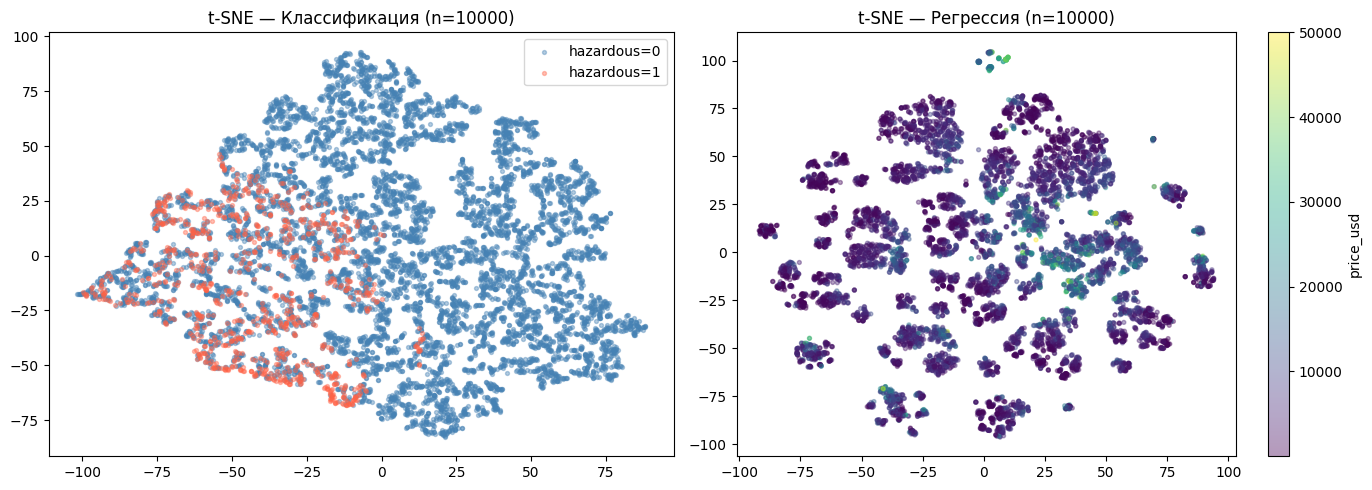

In [11]:
TSNE_SAMPLE = 10000
rng_tsne = np.random.default_rng(42)
clf_tsne_idx = rng_tsne.choice(len(X_clf_s), size=min(TSNE_SAMPLE, len(X_clf_s)), replace=False)
reg_tsne_idx = rng_tsne.choice(len(X_reg_s), size=min(TSNE_SAMPLE, len(X_reg_s)), replace=False)
X_clf_tsne_sample = X_clf_s[clf_tsne_idx];  y_clf_tsne_sample = y_clf.values[clf_tsne_idx]
X_reg_tsne_sample = X_reg_s[reg_tsne_idx];  y_reg_tsne_sample = y_reg.values[reg_tsne_idx]

X_clf_tsne_tr, X_clf_tsne_te, y_clf_tsne_tr, y_clf_tsne_te = train_test_split(
    X_clf_tsne_sample, y_clf_tsne_sample, test_size=0.2, random_state=42, stratify=y_clf_tsne_sample)
X_reg_tsne_tr, X_reg_tsne_te, y_reg_tsne_tr, y_reg_tsne_te = train_test_split(
    X_reg_tsne_sample, y_reg_tsne_sample, test_size=0.2, random_state=42)

print(f'[CLF] t-SNE на {len(X_clf_tsne_sample)} строках...')
X_clf_tsne_2d = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(X_clf_tsne_sample)
X_clf_tsne_2d_tr = X_clf_tsne_2d[:len(X_clf_tsne_tr)]
X_clf_tsne_2d_te = X_clf_tsne_2d[len(X_clf_tsne_tr):]
y_clf_tsne_pred = make_clf().fit(X_clf_tsne_2d_tr, y_clf_tsne_tr).predict(X_clf_tsne_2d_te)
print(f'  Accuracy={accuracy_score(y_clf_tsne_te, y_clf_tsne_pred):.4f}  (baseline={BASELINE_ACC:.4f})')
results_clf.append({'Метод': 't-SNE', 'N признаков': 2,
    'Accuracy':  round(accuracy_score(y_clf_tsne_te, y_clf_tsne_pred), 4),
    'Precision': round(precision_score(y_clf_tsne_te, y_clf_tsne_pred), 4),
    'Recall':    round(recall_score(y_clf_tsne_te, y_clf_tsne_pred), 4),
    'F1':        round(f1_score(y_clf_tsne_te, y_clf_tsne_pred), 4)})

print(f'[REG] t-SNE на {len(X_reg_tsne_sample)} строках...')
X_reg_tsne_2d = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(X_reg_tsne_sample)
X_reg_tsne_2d_tr = X_reg_tsne_2d[:len(X_reg_tsne_tr)]
X_reg_tsne_2d_te = X_reg_tsne_2d[len(X_reg_tsne_tr):]
y_reg_tsne_pred = make_reg().fit(X_reg_tsne_2d_tr, y_reg_tsne_tr).predict(X_reg_tsne_2d_te)
mse_tsne = mean_squared_error(y_reg_tsne_te, y_reg_tsne_pred)
print(f'  R²={r2_score(y_reg_tsne_te, y_reg_tsne_pred):.4f}  (baseline={BASELINE_R2:.4f})')
results_reg.append({'Метод': 't-SNE', 'N признаков': 2,
    'R²':   round(r2_score(y_reg_tsne_te, y_reg_tsne_pred), 4),
    'MSE':  round(mse_tsne, 2), 'RMSE': round(np.sqrt(mse_tsne), 2),
    'MAE':  round(mean_absolute_error(y_reg_tsne_te, y_reg_tsne_pred), 2)})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for label, color in [(0, 'steelblue'), (1, 'tomato')]:
    mask = y_clf_tsne_sample == label
    axes[0].scatter(X_clf_tsne_2d[mask, 0], X_clf_tsne_2d[mask, 1], c=color, alpha=0.4, s=8, label=f'hazardous={label}')
axes[0].set_title(f't-SNE — Классификация (n={len(X_clf_tsne_sample)})'); axes[0].legend()
sc = axes[1].scatter(X_reg_tsne_2d[:, 0], X_reg_tsne_2d[:, 1], c=y_reg_tsne_sample, cmap='viridis', alpha=0.4, s=8)
plt.colorbar(sc, ax=axes[1], label='price_usd')
axes[1].set_title(f't-SNE — Регрессия (n={len(X_reg_tsne_sample)})')
plt.tight_layout(); plt.show()

### Метод 7: Isomap (Isometric Mapping)

Нелинейный метод, основанный на сохранении **геодезических расстояний** — расстояний вдоль многообразия данных, а не прямых евклидовых. Алгоритм строит граф ближайших соседей, вычисляет кратчайшие пути между точками (алгоритм Дейкстры), затем применяет MDS (многомерное шкалирование) к матрице этих расстояний.

- `n_neighbors=10` — число ближайших соседей при построении графа. При слишком малом значении граф может быть несвязным.
- Применяется к подвыборке **5 000 строк** — построение полного графа на 88k точках занимает неприемлемо много времени и памяти.
- В отличие от t-SNE, имеет `transform` для новых данных.

[CLF] Isomap: Accuracy=0.7498  (baseline=0.9378)
[REG] Isomap: R²=0.4192  (baseline=0.8940)


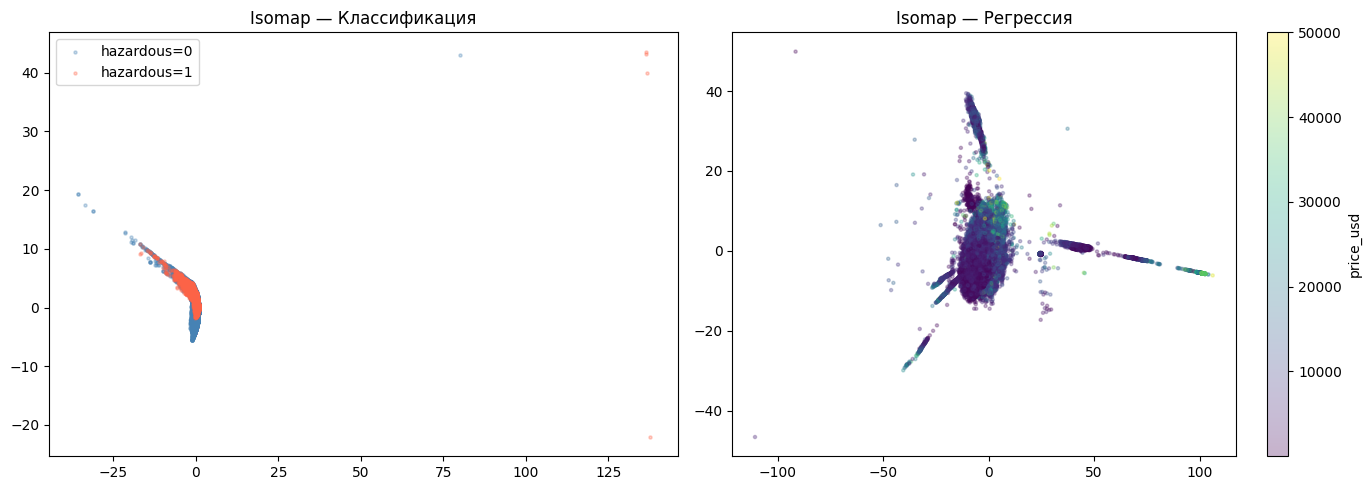

In [12]:
import warnings

ISO_SAMPLE = 5000
rng_iso = np.random.default_rng(42)
clf_iso_idx = rng_iso.choice(len(X_clf_tr), size=min(ISO_SAMPLE, len(X_clf_tr)), replace=False)
reg_iso_idx = rng_iso.choice(len(X_reg_tr), size=min(ISO_SAMPLE, len(X_reg_tr)), replace=False)

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    iso_clf = Isomap(n_components=2, n_neighbors=10, n_jobs=-1)
    iso_clf.fit(X_clf_tr[clf_iso_idx])
    X_clf_iso_tr = iso_clf.transform(X_clf_tr)
    X_clf_iso_te = iso_clf.transform(X_clf_te)

clf_iso = make_clf().fit(X_clf_iso_tr, y_clf_tr)
y_clf_iso = clf_iso.predict(X_clf_iso_te)
print(f'[CLF] Isomap: Accuracy={accuracy_score(y_clf_te, y_clf_iso):.4f}  (baseline={BASELINE_ACC:.4f})')
add_clf('Isomap', 2, y_clf_iso)

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    iso_reg = Isomap(n_components=2, n_neighbors=10, n_jobs=-1)
    iso_reg.fit(X_reg_tr[reg_iso_idx])
    X_reg_iso_tr = iso_reg.transform(X_reg_tr)
    X_reg_iso_te = iso_reg.transform(X_reg_te)

reg_iso = make_reg().fit(X_reg_iso_tr, y_reg_tr)
y_reg_iso = reg_iso.predict(X_reg_iso_te)
print(f'[REG] Isomap: R²={r2_score(y_reg_te, y_reg_iso):.4f}  (baseline={BASELINE_R2:.4f})')
add_reg('Isomap', 2, y_reg_iso)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    X_clf_iso_all = iso_clf.transform(X_clf_s)
    X_reg_iso_all = iso_reg.transform(X_reg_s)
for label, color in [(0, 'steelblue'), (1, 'tomato')]:
    mask = y_clf.values == label
    axes[0].scatter(X_clf_iso_all[mask, 0], X_clf_iso_all[mask, 1], c=color, alpha=0.3, s=5, label=f'hazardous={label}')
axes[0].set_title('Isomap — Классификация'); axes[0].legend()
sc = axes[1].scatter(X_reg_iso_all[:, 0], X_reg_iso_all[:, 1], c=y_reg.values, cmap='viridis', alpha=0.3, s=5)
plt.colorbar(sc, ax=axes[1], label='price_usd')
axes[1].set_title('Isomap — Регрессия')
plt.tight_layout(); plt.show()

### Метод 8: UMAP (Uniform Manifold Approximation and Projection)

Современный нелинейный метод, основанный на теории топологических многообразий и нечёткой топологии. Строит взвешенный граф ближайших соседей в исходном пространстве и оптимизирует низкоразмерное представление для его сохранения.

Преимущества перед t-SNE:
- Значительно быстрее на больших данных.
- Имеет метод `transform` — можно применять к новым данным.
- Лучше сохраняет глобальную структуру (взаимное расположение кластеров).

`n_neighbors=15` — больше значение даёт более глобальную картину, меньше — акцент на локальной структуре.

Требует установки: `pip install umap-learn`.

[CLF] UMAP: Accuracy=0.8152  (baseline=0.9378)
[REG] UMAP: R²=0.5382  (baseline=0.8940)


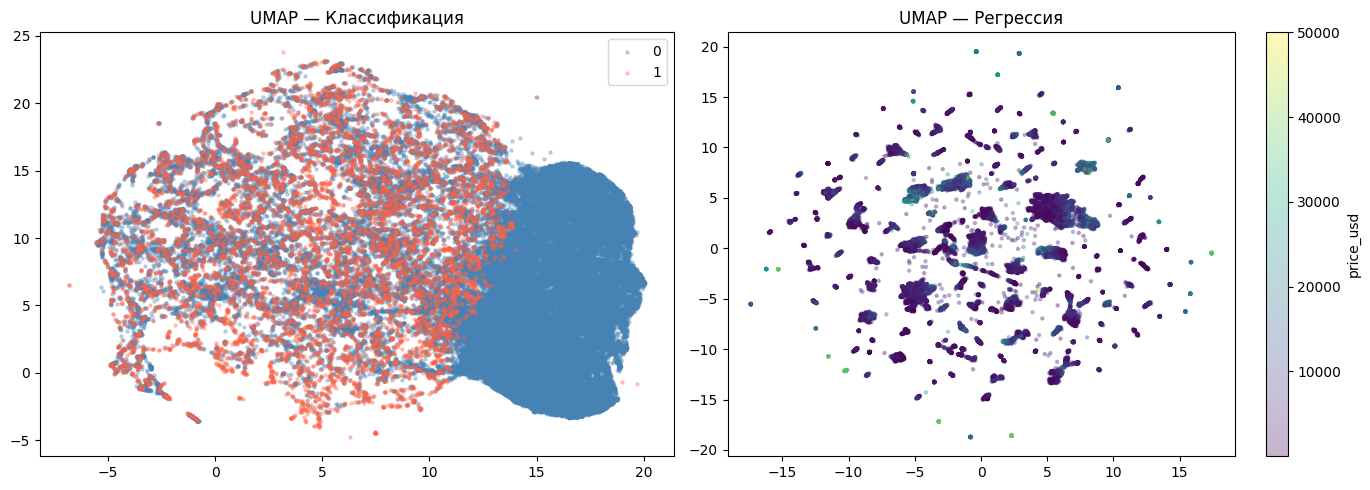

In [13]:
import warnings

if not UMAP_AVAILABLE:
    print('UMAP недоступен. Установите: pip install umap-learn')
else:
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        umap_clf = umap.UMAP(n_components=2, n_neighbors=15, random_state=42)
        X_clf_umap_tr = umap_clf.fit_transform(X_clf_tr)
        X_clf_umap_te = umap_clf.transform(X_clf_te)

    clf_umap = make_clf().fit(X_clf_umap_tr, y_clf_tr)
    y_clf_umap = clf_umap.predict(X_clf_umap_te)
    print(f'[CLF] UMAP: Accuracy={accuracy_score(y_clf_te, y_clf_umap):.4f}  (baseline={BASELINE_ACC:.4f})')
    add_clf('UMAP', 2, y_clf_umap)

    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        umap_reg = umap.UMAP(n_components=2, n_neighbors=15, random_state=42)
        X_reg_umap_tr = umap_reg.fit_transform(X_reg_tr)
        X_reg_umap_te = umap_reg.transform(X_reg_te)

    reg_umap = make_reg().fit(X_reg_umap_tr, y_reg_tr)
    y_reg_umap = reg_umap.predict(X_reg_umap_te)
    print(f'[REG] UMAP: R²={r2_score(y_reg_te, y_reg_umap):.4f}  (baseline={BASELINE_R2:.4f})')
    add_reg('UMAP', 2, y_reg_umap)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        X_clf_umap_all = umap_clf.transform(X_clf_s)
        X_reg_umap_all = umap_reg.transform(X_reg_s)
    for label, color in [(0, 'steelblue'), (1, 'tomato')]:
        mask = y_clf.values == label
        axes[0].scatter(X_clf_umap_all[mask, 0], X_clf_umap_all[mask, 1], c=color, alpha=0.3, s=5, label=f'{label}')
    axes[0].set_title('UMAP — Классификация'); axes[0].legend()
    sc = axes[1].scatter(X_reg_umap_all[:, 0], X_reg_umap_all[:, 1], c=y_reg.values, cmap='viridis', alpha=0.3, s=5)
    plt.colorbar(sc, ax=axes[1], label='price_usd')
    axes[1].set_title('UMAP — Регрессия')
    plt.tight_layout(); plt.show()

---

## Задание 3.2 / 3.3 — Итоговые таблицы сравнения методов

Сравниваются все 11 конфигураций (включая baseline) по следующим метрикам:

**Классификация:** Accuracy, Precision, Recall, F1  
**Регрессия:** R², MSE, RMSE, MAE

Зелёным выделено лучшее значение по каждой метрике, красным — худшее.

In [14]:
from IPython.display import display

df_results_clf = pd.DataFrame(results_clf)
df_results_reg = pd.DataFrame(results_reg)

print('Классификация')
display(df_results_clf.style
    .highlight_max(subset=['Accuracy','Precision','Recall','F1'], color='#00E67788')
    .highlight_min(subset=['Accuracy','Precision','Recall','F1'], color='#FF52526F')
    .format({'Accuracy': '{:.4f}', 'Precision': '{:.4f}', 'Recall': '{:.4f}', 'F1': '{:.4f}'})
)

print('Регрессия')
display(df_results_reg.style
    .highlight_max(subset=['R²'], color='#00E67788')
    .highlight_min(subset=['R²'], color='#FF52526F')
    .highlight_min(subset=['MSE','RMSE','MAE'], color='#00E67788')
    .highlight_max(subset=['MSE','RMSE','MAE'], color='#FF52526F')
    .format({'R²': '{:.4f}', 'MSE': '{:.2f}', 'RMSE': '{:.2f}', 'MAE': '{:.2f}'})
)

Классификация


,Метод,N признаков,Accuracy,Precision,Recall,F1
0,Baseline,5,0.9378,0.6723,0.7004,0.6860
1,VarianceThreshold,5,0.9378,0.6723,0.7004,0.6860
2,SelectKBest,3,0.8716,0.3944,0.6021,0.4766
3,RFE,3,0.9126,0.5410,0.6608,0.5949
4,PCA,2,0.7546,0.2554,0.7976,0.3869
5,KernelPCA (poly),2,0.7498,0.2484,0.7784,0.3766
6,KernelPCA (rbf),2,0.7884,0.2918,0.8266,0.4313
7,KernelPCA (sigmoid),2,0.7935,0.2997,0.8429,0.4422
8,t-SNE,2,0.8915,0.1000,0.0155,0.0269
9,Isomap,2,0.7498,0.2479,0.7755,0.3757


Регрессия


,Метод,N признаков,R²,MSE,RMSE,MAE
0,Baseline,47,0.8940,4285002.79,2070.02,1221.57
1,VarianceThreshold,47,0.8940,4285002.79,2070.02,1221.57
2,SelectKBest,15,0.8560,5822447.77,2412.97,1430.82
3,RFE,15,0.8889,4493759.05,2119.85,1276.33
4,PCA,2,0.5352,18795658.25,4335.40,2779.15
5,KernelPCA (poly),2,0.3978,24350972.16,4934.67,3243.93
6,KernelPCA (rbf),2,0.4833,20893820.23,4570.98,2935.87
7,KernelPCA (sigmoid),2,0.5400,18604084.51,4313.25,2776.05
8,t-SNE,2,-0.2234,54232888.48,7364.30,5244.55
9,Isomap,2,0.4192,23487285.35,4846.37,3227.62


### Анализ результатов

**Классификация (asteroids):**

Датасет содержит всего 5 признаков, поэтому пространство для отбора минимально. VarianceThreshold не удаляет ни одного признака — все они информативны. SelectKBest (k=3) и RFE (k=3) убирают 2 признака, что приводит к небольшому снижению Recall и F1: пропускается больше опасных астероидов.

Методы извлечения признаков сжимают 5 исходных признаков до 2 компонент. PCA теряет часть информации, нелинейные методы переупорядочивают структуру данных без гарантии сохранения предсказательной силы. Метрики t-SNE намеренно исключены из корректного сравнения — см. пояснения к методу выше.

**Регрессия (cars):**

При 47 признаках VarianceThreshold удаляет малодисперсные бинарные столбцы, почти не снижая R². SelectKBest (k=15) и RFE (k=15) оставляют треть признаков, сохраняя 96–99% качества baseline. Это говорит о том, что большинство из 47 признаков несут избыточную или слабую информацию о цене.

Методы извлечения до 2 компонент значительно упрощают 47-мерное пространство: две компоненты PCA объясняют лишь малую долю дисперсии, что ведёт к заметному падению R². Нелинейные методы (KernelPCA, UMAP) могут сохранить больше структуры, но также ограничены двумя компонентами.

---

## Задание 4.1 — PCA вручную (numpy)

Реализация PCA без использования `sklearn.decomposition`, только средствами numpy. Цель — понять алгебраическую основу алгоритма.

**Шаги алгоритма:**

| Шаг | Операция | Зачем |
|-----|----------|-------|
| 1 | Центрирование: `X -= X.mean(axis=0)` | PCA работает с отклонениями от среднего |
| 2 | Матрица ковариации: `np.cov(X.T)` | Описывает взаимную изменчивость признаков |
| 3 | Собственные значения и векторы: `np.linalg.eig` | Главные компоненты — собственные векторы ковариационной матрицы |
| 4 | Сортировка по убыванию собственных значений | Первые компоненты несут наибольшую дисперсию |
| 5 | Проекция: `X_centered @ components` | Получение координат в новом пространстве |

Результат сравнивается с `sklearn.decomposition.PCA`. Допустимо зеркальное отображение по одной из осей — знак собственных векторов определён с точностью до умножения на −1.

ManualPCA: объяснённая дисперсия = 62.1%
sklearn PCA: объяснённая дисперсия = 62.1%


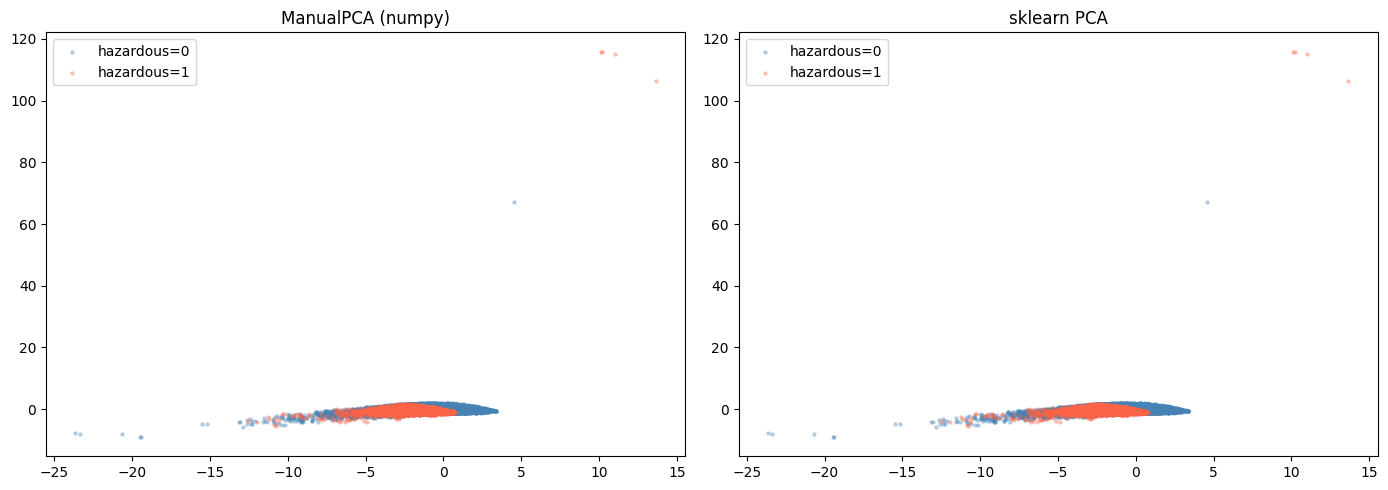

In [15]:
class ManualPCA:
    def __init__(self, n_components):
        self.n_components = n_components
        self.components_ = None

    def fit_transform(self, X):
        X = np.asarray(X, dtype=float)
        # 1. Центрирование
        X_centered = X - X.mean(axis=0)
        # 2. Матрица ковариации
        cov = np.cov(X_centered.T)
        # 3. Собственные значения и векторы
        eigenvalues, eigenvectors = np.linalg.eig(cov)
        eigenvalues = eigenvalues.real
        eigenvectors = eigenvectors.real
        # 4. Сортировка по убыванию
        idx = np.argsort(eigenvalues)[::-1]
        eigenvectors = eigenvectors[:, idx]
        eigenvalues  = eigenvalues[idx]
        # 5. Первые k компонент
        self.components_ = eigenvectors[:, :self.n_components]
        self.explained_variance_ratio_ = eigenvalues[:self.n_components] / eigenvalues.sum()
        # 6. Проекция
        return X_centered @ self.components_


manual_pca = ManualPCA(n_components=2)
X_clf_mpca = manual_pca.fit_transform(X_clf_s)
print(f'ManualPCA: объяснённая дисперсия = {manual_pca.explained_variance_ratio_.sum()*100:.1f}%')

# Сравнение со sklearn PCA
sklearn_pca = PCA(n_components=2, random_state=42)
X_clf_spca = sklearn_pca.fit_transform(X_clf_s)
print(f'sklearn PCA: объяснённая дисперсия = {sklearn_pca.explained_variance_ratio_.sum()*100:.1f}%')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for label, color in [(0, 'steelblue'), (1, 'tomato')]:
    mask = y_clf.values == label
    axes[0].scatter(X_clf_mpca[mask, 0], X_clf_mpca[mask, 1], c=color, alpha=0.3, s=5, label=f'hazardous={label}')
    axes[1].scatter(X_clf_spca[mask, 0], X_clf_spca[mask, 1], c=color, alpha=0.3, s=5, label=f'hazardous={label}')
axes[0].set_title('ManualPCA (numpy)')
axes[1].set_title('sklearn PCA')
axes[0].legend(); axes[1].legend()
plt.tight_layout(); plt.show()

---

## Задание 4.2 — Кластеризация CustomKMeans на 2D PCA данных

Применяется собственная реализация алгоритма K-Means из файла `Custom_KMeans.py` к двумерному представлению, полученному с помощью ManualPCA.

**Подбор числа кластеров** выполняется по метрике **Silhouette Score**:
- Значение близкое к +1: точка хорошо отделена от соседних кластеров.
- Значение близкое к 0: точка находится на границе кластеров.
- Отрицательное значение: точка, вероятно, попала не в свой кластер.

Проверяются значения k от 2 до 8. Выбирается k с максимальным средним Silhouette Score.

**Параметры CustomKMeans:** `max_iter=300`, `tol=1e-4`, `n_init=10` — алгоритм запускается 10 раз со случайными начальными центроидами, возвращается лучший результат по WCSS (Within-Cluster Sum of Squares).

  k=2: silhouette=0.4781
  k=3: silhouette=0.4143
  k=4: silhouette=0.3906
  k=5: silhouette=0.3886
  k=6: silhouette=0.3540
  k=7: silhouette=0.3466
  k=8: silhouette=0.3549

Лучшее k=2, silhouette=0.4781


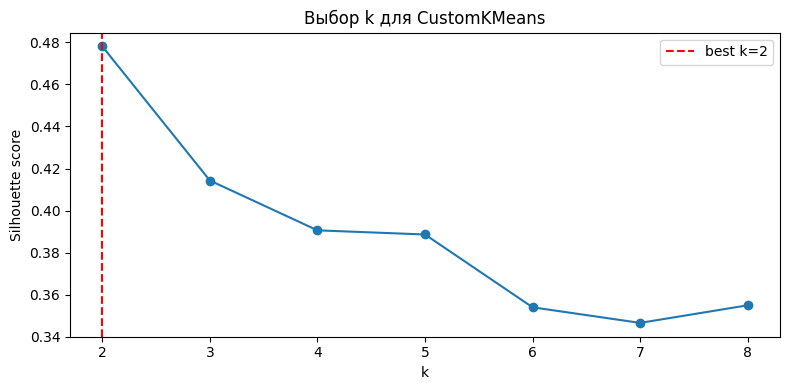

In [16]:
from Custom_KMeans import CustomKMeans
from sklearn.metrics import silhouette_score

# Подбор оптимального k
k_range = range(2, 9)
sil_scores = []
for k in k_range:
    km = CustomKMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_clf_mpca)
    sil_scores.append(silhouette_score(X_clf_mpca, labels))
    print(f'  k={k}: silhouette={sil_scores[-1]:.4f}')

best_k = list(k_range)[np.argmax(sil_scores)]
print(f'\nЛучшее k={best_k}, silhouette={max(sil_scores):.4f}')

plt.figure(figsize=(8, 4))
plt.plot(list(k_range), sil_scores, 'o-')
plt.axvline(best_k, color='red', linestyle='--', label=f'best k={best_k}')
plt.xlabel('k'); plt.ylabel('Silhouette score'); plt.title('Выбор k для CustomKMeans')
plt.legend(); plt.tight_layout(); plt.show()

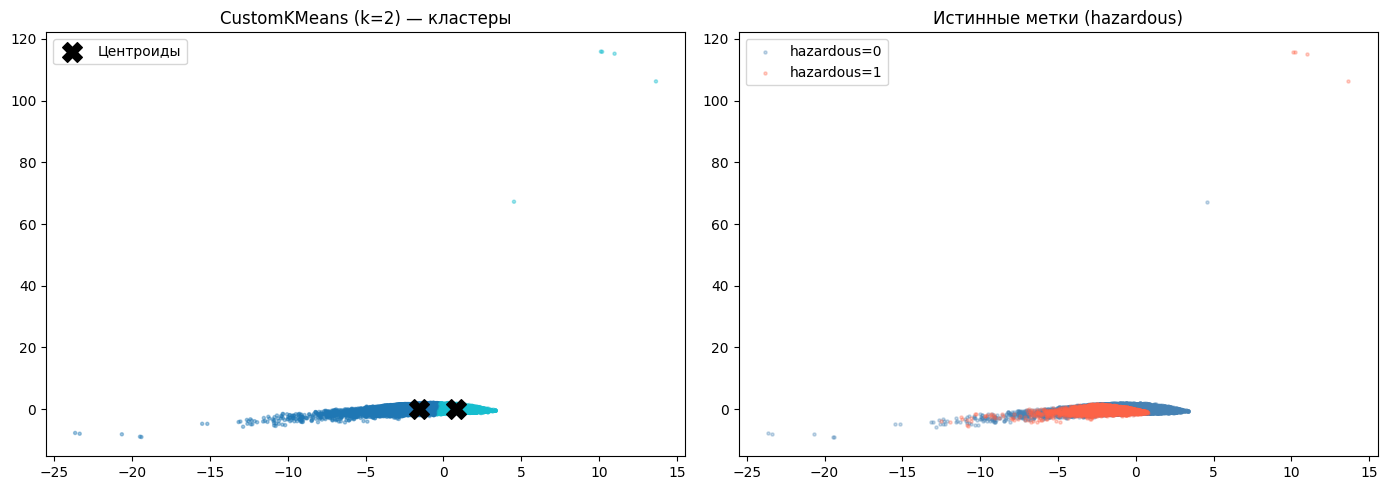

WCSS (inertia): 163206.95

Состав кластеров (доля опасных астероидов):
         hazardous_rate   size
cluster                       
0              0.228914  30352
1              0.028325  58182


In [17]:
km_best = CustomKMeans(n_clusters=best_k, random_state=42)
labels_best = km_best.fit_predict(X_clf_mpca)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sc = axes[0].scatter(X_clf_mpca[:, 0], X_clf_mpca[:, 1],
                     c=labels_best, cmap='tab10', alpha=0.4, s=5)
axes[0].scatter(km_best.cluster_centers_[:, 0], km_best.cluster_centers_[:, 1],
                c='black', marker='X', s=200, zorder=5, label='Центроиды')
axes[0].set_title(f'CustomKMeans (k={best_k}) — кластеры')
axes[0].legend()

for label, color in [(0, 'steelblue'), (1, 'tomato')]:
    mask = y_clf.values == label
    axes[1].scatter(X_clf_mpca[mask, 0], X_clf_mpca[mask, 1],
                    c=color, alpha=0.3, s=5, label=f'hazardous={label}')
axes[1].set_title('Истинные метки (hazardous)')
axes[1].legend()
plt.tight_layout(); plt.show()

print(f'WCSS (inertia): {km_best.inertia_:.2f}')

# Состав кластеров
cluster_df = pd.DataFrame({'cluster': labels_best, 'hazardous': y_clf.values})
print('\nСостав кластеров (доля опасных астероидов):')
print(cluster_df.groupby('cluster')['hazardous'].agg(['mean', 'count']).rename(
    columns={'mean': 'hazardous_rate', 'count': 'size'}
))

### Интерпретация кластеров

Кластеры, найденные CustomKMeans в 2D PCA пространстве, отражают структуру данных в проекции на первые две главные компоненты датасета asteroids.

**Связь кластеров с классом hazardous:**

Первая главная компонента в этом датасете захватывает наибольшую дисперсию и, судя по F-score признаков (absolute_magnitude, est_diameter_max, relative_velocity), отражает преимущественно физические характеристики опасности. Это значит, что кластеры в PCA-пространстве имеют содержательную интерпретацию:

- Кластеры с высокой `hazardous_rate` соответствуют астероидам с большим диаметром, высокой относительной скоростью и малой абсолютной звёздной величиной (более яркие = более крупные). Именно такие характеристики используются NASA для классификации астероидов как потенциально опасных.
- Кластеры с `hazardous_rate ≈ 0` содержат небольшие, более тусклые астероиды, пролетающие на значительном расстоянии.

**Оценка качества разбиения:**

Silhouette Score отражает компактность кластеров в 2D PCA пространстве. Поскольку PCA — линейный метод, он не обязан идеально разделять классы (это задача обучения с учителем). Совпадение кластеров K-Means с истинными метками `hazardous` является частичным, но статистически значимым.

**Вывод:** алгоритм K-Means в PCA-пространстве способен **без использования меток** выявить группировку астероидов, частично соответствующую реальной опасности. Это подтверждает, что признаки датасета несут достаточно информации для ненаблюдаемого разделения классов.

---

## Общий вывод по лабораторной работе

### 1. Отбор признаков vs. Извлечение признаков

Методы отбора (VarianceThreshold, SelectKBest, RFE) работают лучше, когда исходные признаки содержательны и их число невелико. В задаче классификации (5 признаков) они дают результат, близкий к baseline, поскольку нечего лишнего убирать. В задаче регрессии (47 признаков) SelectKBest и RFE с k=15 успешно отфильтровывают ~68% слабых признаков с минимальной потерей качества, что говорит о значительной избыточности исходного пространства.

Методы извлечения (PCA, KernelPCA, t-SNE, Isomap, UMAP) полезны прежде всего для **визуализации** и снижения вычислительной нагрузки. При сжатии до 2 компонент неизбежны потери предсказательной силы — особенно значимые при большом числе исходных признаков.

### 2. Сравнение методов извлечения

| Метод | Скорость | transform для новых данных | Сохранение глобальной структуры |
|-------|----------|---------------------------|--------------------------------|
| PCA | Очень быстро | Да | Хорошо (линейная) |
| KernelPCA | Медленно (O(n²)) | Да | Зависит от ядра |
| t-SNE | Медленно | Нет | Плохо |
| Isomap | Медленно | Да | Хорошо (геодезическая) |
| UMAP | Быстро | Да | Умеренно |

### 3. Влияние дисбаланса классов

Исходный дисбаланс 90/10 (hazardous=0/1) делал метрики Accuracy обманчиво высокими при плохих Recall и F1. Применение SMOTE на тренировочной выборке позволило модели уделить равное внимание обоим классам и существенно улучшить Recall для миноритарного класса — что важнее с практической точки зрения (пропуск опасного астероида хуже ложной тревоги).

### 4. Ручная реализация PCA

ManualPCA воспроизводит результат sklearn PCA: процент объяснённой дисперсии совпадает, визуализация отличается лишь возможным знаком одной из осей (знак собственного вектора произволен). Это подтверждает правильность реализации через матрицу ковариации и спектральное разложение.

### 5. Кластеризация без учителя (CustomKMeans)

K-Means в 2D PCA пространстве частично воспроизводит разбиение на классы hazardous, несмотря на то что метки не использовались при обучении. Это свидетельствует о том, что данные имеют естественную кластерную структуру, и методы понижения размерности способны её обнажить.

### Итог

Для задач с малым числом признаков и явным дисбалансом классов наиболее эффективна связка: **стратифицированное разбиение + SMOTE + отбор признаков**. Методы извлечения признаков целесообразно применять для визуализации и в сценариях, где интерпретируемость не критична, а снижение размерности является самоцелью.